# 03B Fine-Tuned Baseline Model

## MobileSkinXAI Thesis Project

This notebook improves the initial frozen-baseline experiment by training a fine-tuned MobileNetV2 model.

Improvements over Notebook 03:

- Data augmentation
- Two-stage training
- Frozen backbone training
- Fine-tuning top layers
- Class weighting
- Internal ISIC2019 evaluation
- External PAD-UFES-20 evaluation
- Confusion matrix
- Balanced accuracy, MCC, Cohen’s Kappa
- Model size and inference time

In [1]:
import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
IMG_SIZE = 224
BATCH_SIZE = 32

STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 15

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
NOTEBOOK02_OUTPUT = Path(
    "/kaggle/input/notebooks/rinvijaman/02-preprocessing-pipeline-ipynb"
)

SPLITS_DIR = NOTEBOOK02_OUTPUT / "splits"
RESULTS_INPUT_DIR = NOTEBOOK02_OUTPUT / "results"

WORKING_DIR = Path("/kaggle/working")
RESULTS_DIR = WORKING_DIR / "results"
MODELS_DIR = WORKING_DIR / "models"
FIGURES_DIR = WORKING_DIR / "figures"
PREDICTIONS_DIR = WORKING_DIR / "predictions"

for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR, PREDICTIONS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "validation.csv")
test_df = pd.read_csv(SPLITS_DIR / "internal_test.csv")
external_df = pd.read_csv(SPLITS_DIR / "external_padufes20_test.csv")

with open(RESULTS_INPUT_DIR / "label_mapping.json", "r") as f:
    label_mapping = json.load(f)

with open(RESULTS_INPUT_DIR / "class_weights.json", "r") as f:
    class_weights_raw = json.load(f)

label_to_index = label_mapping["label_to_index"]
index_to_label = {int(k): v for k, v in label_mapping["index_to_label"].items()}

CLASS_NAMES = [index_to_label[i] for i in range(len(index_to_label))]
NUM_CLASSES = len(CLASS_NAMES)

class_weights = {int(k): float(v) for k, v in class_weights_raw.items()}

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Internal Test:", test_df.shape)
print("External Test:", external_df.shape)
print("Classes:", CLASS_NAMES)
print("Class weights:", class_weights)

Train: (17387, 8)
Validation: (3726, 8)
Internal Test: (3726, 8)
External Test: (2298, 8)
Classes: ['AK', 'BCC', 'BKL', 'MEL', 'NV', 'SCC']
Class weights: {0: 4.774025260845689, 1: 1.2458440813986815, 2: 1.5774814008346942, 3: 0.9155871511321748, 4: 0.3215527444888297, 5: 6.585984848484848}


In [3]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_image(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)

    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, max_delta=0.08)
        image = tf.image.random_contrast(image, lower=0.85, upper=1.15)

    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label


def create_dataset(df, shuffle=False, augment=False):
    paths = df["path"].astype(str).values
    labels = df["label_index"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(len(df), seed=RANDOM_STATE, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda x, y: preprocess_image(x, y, augment=augment),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


train_ds = create_dataset(train_df, shuffle=True, augment=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)
external_ds = create_dataset(external_df)

print("Datasets created successfully.")

I0000 00:00:1783007078.936368      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783007078.939316      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets created successfully.


In [4]:
def build_mobilenetv2_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_Finetuned")

    return model, base_model


model, base_model = build_mobilenetv2_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,790 (8.66 MB)

 Trainable params: 10,246 (40.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [5]:
stage1_checkpoint = MODELS_DIR / "MobileNetV2_stage1_best.keras"

callbacks_stage1 = [
    ModelCheckpoint(
        stage1_checkpoint,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

start_time = time.time()

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_stage1,
    verbose=1
)

stage1_time = time.time() - start_time

print("Stage 1 training time:", round(stage1_time / 60, 2), "minutes")

Epoch 1/10


2026-07-02 15:44:59.256156: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 15:44:59.393283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783007101.801240      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2005 - loss: 2.4372

2026-07-02 15:46:41.943352: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 15:46:42.092289: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 15:46:42.229843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.2006 - loss: 2.4368

2026-07-02 15:47:17.053259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 15:47:17.190377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.41653, saving model to /kaggle/working/models/MobileNetV2_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/models/MobileNetV2_stage1_best.keras
544/544 ━━━━━━━━━━━━━━━━━━━━ 158s 254ms/step - accuracy: 0.2607 - loss: 2.2151 - val_accuracy: 0.4165 - val_loss: 1.6197 - learning_rate: 1.0000e-04
Epoch 2/10
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3830 - loss: 1.8826
Epoch 2: val_accuracy improved from 0.41653 to 0.48739, saving model to /kaggle/working/models/MobileNetV2_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/models/MobileNetV2_stage1_best.keras
544/544 ━━━━━━━━━━━━━━━━━━━━ 77s 141ms/step - accuracy: 0.4032 - loss: 1.8359 - val_accuracy: 0.4874 - val_loss: 1.4389 - learning_rate: 1.0000e-04
Epoch 3/10
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4488 - loss: 1.7300
Epoch 3: val_accuracy improved from 0.48739 to 0.51342, saving model to /kaggle/working/models/MobileNe

In [6]:
base_model.trainable = True

# Fine-tune only the top layers
fine_tune_at = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage2_checkpoint = MODELS_DIR / "MobileNetV2_finetuned_best.keras"

callbacks_stage2 = [
    ModelCheckpoint(
        stage2_checkpoint,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

start_time = time.time()

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_stage2,
    verbose=1
)

stage2_time = time.time() - start_time

print("Stage 2 fine-tuning time:", round(stage2_time / 60, 2), "minutes")

Epoch 1/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4400 - loss: 1.6180
Epoch 1: val_accuracy improved from None to 0.58535, saving model to /kaggle/working/models/MobileNetV2_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/models/MobileNetV2_finetuned_best.keras
544/544 ━━━━━━━━━━━━━━━━━━━━ 109s 160ms/step - accuracy: 0.4610 - loss: 1.5727 - val_accuracy: 0.5853 - val_loss: 1.3313 - learning_rate: 1.0000e-05
Epoch 2/15
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5015 - loss: 1.4270
Epoch 2: val_accuracy improved from 0.58535 to 0.60306, saving model to /kaggle/working/models/MobileNetV2_finetuned_best.keras

Epoch 2: finished saving model to /kaggle/working/models/MobileNetV2_finetuned_best.keras
544/544 ━━━━━━━━━━━━━━━━━━━━ 68s 125ms/step - accuracy: 0.5047 - loss: 1.4129 - val_accuracy: 0.6031 - val_loss: 1.1990 - learning_rate: 1.0000e-05
Epoch 3/15
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5423 - loss: 1.2841
Epoc

In [7]:
base_model.trainable = True

# Fine-tune only the top layers
fine_tune_at = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage2_checkpoint = MODELS_DIR / "MobileNetV2_finetuned_best.keras"

callbacks_stage2 = [
    ModelCheckpoint(
        stage2_checkpoint,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

start_time = time.time()

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_stage2,
    verbose=1
)

stage2_time = time.time() - start_time

print("Stage 2 fine-tuning time:", round(stage2_time / 60, 2), "minutes")

Epoch 1/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6565 - loss: 0.8524
Epoch 1: val_accuracy improved from None to 0.66989, saving model to /kaggle/working/models/MobileNetV2_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/models/MobileNetV2_finetuned_best.keras
544/544 ━━━━━━━━━━━━━━━━━━━━ 109s 161ms/step - accuracy: 0.6547 - loss: 0.8690 - val_accuracy: 0.6699 - val_loss: 0.9213 - learning_rate: 1.0000e-05
Epoch 2/15
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6568 - loss: 0.8352
Epoch 2: val_accuracy did not improve from 0.66989
544/544 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - accuracy: 0.6619 - loss: 0.8358 - val_accuracy: 0.6597 - val_loss: 0.9417 - learning_rate: 1.0000e-05
Epoch 3/15
543/544 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6677 - loss: 0.8080
Epoch 3: val_accuracy did not improve from 0.66989

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
544/544 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step

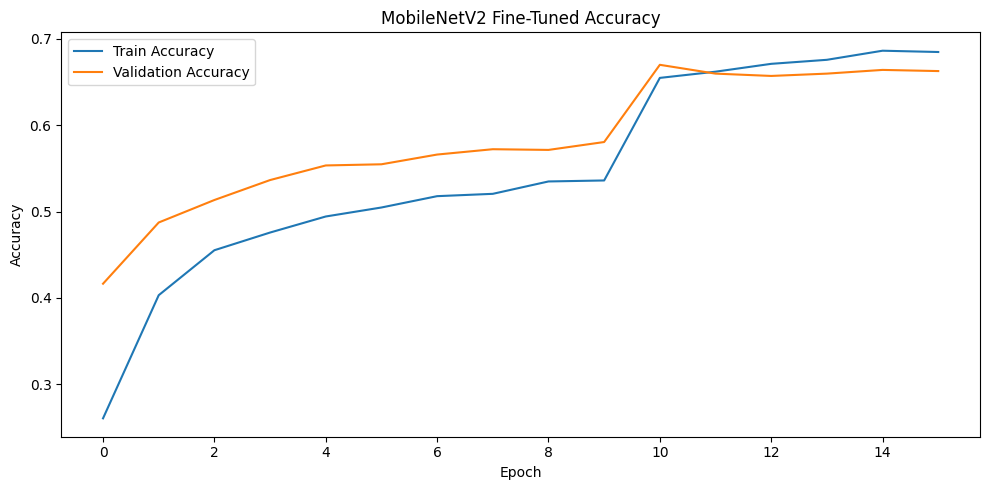

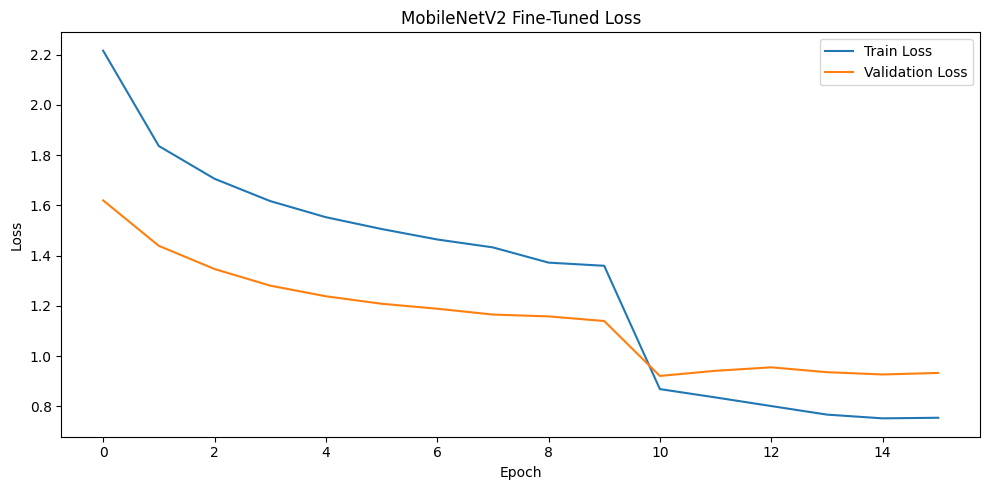

In [8]:
def combine_history(h1, h2):
    combined = {}

    for key in h1.history.keys():
        combined[key] = h1.history[key] + h2.history[key]

    return combined


history = combine_history(history_stage1, history_stage2)

plt.figure(figsize=(10, 5))
plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Fine-Tuned Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "MobileNetV2_finetuned_accuracy_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Fine-Tuned Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "MobileNetV2_finetuned_loss_curve.png", dpi=300)
plt.show()

In [9]:
best_model = tf.keras.models.load_model(stage2_checkpoint)

def evaluate_model(model, dataset, df, split_name):
    y_true = df["label_index"].astype(int).values

    y_prob = model.predict(dataset, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    metrics = {
        "Model": "MobileNetV2_Finetuned",
        "Split": split_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision_Weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_Weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen_Kappa": cohen_kappa_score(y_true, y_pred)
    }

    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()
    cm = confusion_matrix(y_true, y_pred)

    report_df.to_csv(RESULTS_DIR / f"MobileNetV2_finetuned_{split_name}_classification_report.csv")

    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        RESULTS_DIR / f"MobileNetV2_finetuned_{split_name}_confusion_matrix.csv"
    )

    pred_df = df[["image_id", "path", "label", "label_index"]].copy()
    pred_df["pred_index"] = y_pred
    pred_df["pred_label"] = [CLASS_NAMES[i] for i in y_pred]

    for i, cls in enumerate(CLASS_NAMES):
        pred_df[f"prob_{cls}"] = y_prob[:, i]

    pred_df.to_csv(
        PREDICTIONS_DIR / f"MobileNetV2_finetuned_{split_name}_predictions.csv",
        index=False
    )

    return metrics, report_df, cm

In [10]:
internal_metrics, internal_report, internal_cm = evaluate_model(
    best_model,
    test_ds,
    test_df,
    "internal_test"
)

external_metrics, external_report, external_cm = evaluate_model(
    best_model,
    external_ds,
    external_df,
    "external_pad_test"
)

metrics_df = pd.DataFrame([internal_metrics, external_metrics])
display(metrics_df)

metrics_df.to_csv(
    RESULTS_DIR / "MobileNetV2_finetuned_metrics.csv",
    index=False
)

display(internal_report)
display(external_report)

117/117 ━━━━━━━━━━━━━━━━━━━━ 28s 198ms/step
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step

2026-07-02 16:25:12.317407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 16:25:12.454648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 651ms/step


,Model,Split,Accuracy,Balanced_Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,F1_Macro,MCC,Cohen_Kappa
0,MobileNetV2_Finetuned,internal_test,0.670424,0.611851,0.718837,0.670424,0.687116,0.547102,0.540119,0.535265
1,MobileNetV2_Finetuned,external_pad_test,0.283725,0.316695,0.439527,0.283725,0.307291,0.262302,0.156437,0.143751


,precision,recall,f1-score,support
AK,0.299625,0.615385,0.403023,130.000000
BCC,0.622776,0.702811,0.660377,498.000000
BKL,0.474501,0.544529,0.507109,393.000000
MEL,0.575758,0.559647,0.567588,679.000000
NV,0.894605,0.738095,0.808849,1932.000000
SCC,0.250000,0.510638,0.335664,94.000000
accuracy,0.670424,0.670424,0.670424,0.670424
macro avg,0.519544,0.611851,0.547102,3726.000000
weighted avg,0.718837,0.670424,0.687116,3726.000000


,precision,recall,f1-score,support
AK,0.458924,0.221918,0.299169,730.000000
BCC,0.610942,0.237870,0.342419,845.000000
BKL,0.136364,0.421277,0.206035,235.000000
MEL,0.054795,0.230769,0.088561,52.000000
NV,0.388199,0.512295,0.441696,244.000000
SCC,0.151862,0.276042,0.195933,192.000000
accuracy,0.283725,0.283725,0.283725,0.283725
macro avg,0.300181,0.316695,0.262302,2298.000000
weighted avg,0.439527,0.283725,0.307291,2298.000000


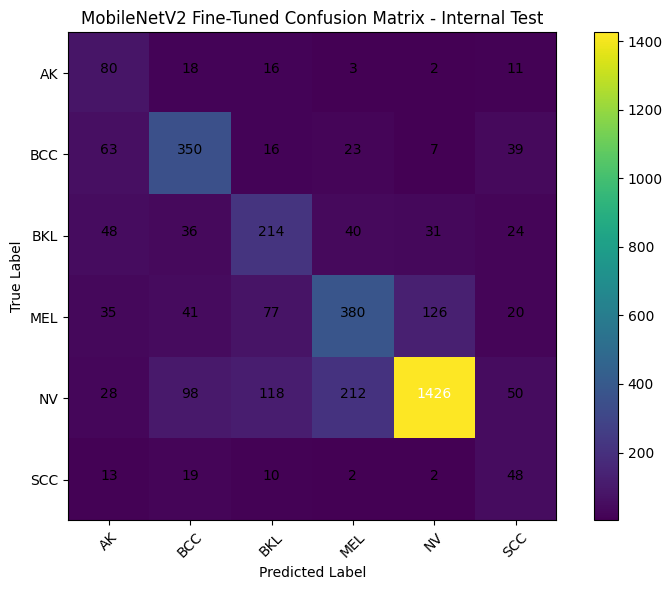

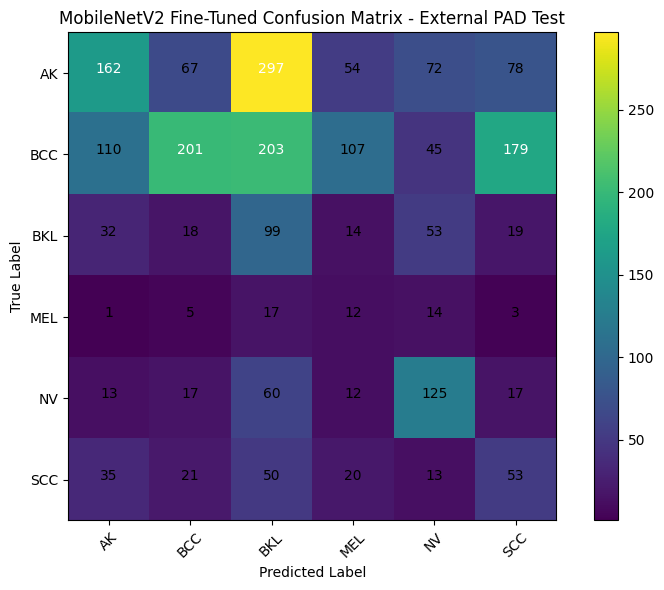

In [11]:
def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(CLASS_NAMES))
    plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
    plt.yticks(tick_marks, CLASS_NAMES)

    thresh = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(
    internal_cm,
    "MobileNetV2 Fine-Tuned Confusion Matrix - Internal Test",
    "MobileNetV2_finetuned_internal_confusion_matrix.png"
)

plot_confusion_matrix(
    external_cm,
    "MobileNetV2 Fine-Tuned Confusion Matrix - External PAD Test",
    "MobileNetV2_finetuned_external_confusion_matrix.png"
)

In [12]:
model_path = stage2_checkpoint
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("Model size:", round(model_size_mb, 2), "MB")

sample_ds = test_ds.take(10)

start_time = time.time()

num_images = 0

for batch_images, _ in sample_ds:
    _ = best_model.predict(batch_images, verbose=0)
    num_images += batch_images.shape[0]

total_time = time.time() - start_time

ms_per_image = (total_time / num_images) * 1000
fps = num_images / total_time

efficiency_metrics = {
    "Model": "MobileNetV2_Finetuned",
    "Model_Size_MB": model_size_mb,
    "Inference_ms_per_image": ms_per_image,
    "FPS": fps,
    "Stage1_Training_Minutes": stage1_time / 60,
    "Stage2_Training_Minutes": stage2_time / 60
}

efficiency_df = pd.DataFrame([efficiency_metrics])
display(efficiency_df)

efficiency_df.to_csv(
    RESULTS_DIR / "MobileNetV2_finetuned_efficiency_metrics.csv",
    index=False
)

Model size: 23.07 MB


,Model,Model_Size_MB,Inference_ms_per_image,FPS,Stage1_Training_Minutes,Stage2_Training_Minutes
0,MobileNetV2_Finetuned,23.070765,19.837115,50.410556,13.138912,7.834791


In [13]:
print("=" * 80)
print("MobileNetV2 Fine-Tuned Baseline Completed")
print("=" * 80)

print("\nInternal Test:")
print(internal_metrics)

print("\nExternal PAD Test:")
print(external_metrics)

print("\nEfficiency:")
print(efficiency_metrics)

print("\nSaved model:")
print(stage2_checkpoint)

MobileNetV2 Fine-Tuned Baseline Completed

Internal Test:
{'Model': 'MobileNetV2_Finetuned', 'Split': 'internal_test', 'Accuracy': 0.6704240472356414, 'Balanced_Accuracy': np.float64(0.6118508662411016), 'Precision_Weighted': 0.7188374666658618, 'Recall_Weighted': 0.6704240472356414, 'F1_Weighted': 0.6871161157406872, 'F1_Macro': 0.5471016124291689, 'MCC': np.float64(0.5401191518411058), 'Cohen_Kappa': np.float64(0.5352647633917431)}

External PAD Test:
{'Model': 'MobileNetV2_Finetuned', 'Split': 'external_pad_test', 'Accuracy': 0.28372497824194953, 'Balanced_Accuracy': np.float64(0.3166950343086961), 'Precision_Weighted': 0.4395270776960045, 'Recall_Weighted': 0.28372497824194953, 'F1_Weighted': 0.3072907006160896, 'F1_Macro': 0.2623023150325123, 'MCC': np.float64(0.15643657423827054), 'Cohen_Kappa': np.float64(0.14375143603842422)}

Efficiency:
{'Model': 'MobileNetV2_Finetuned', 'Model_Size_MB': 23.070765495300293, 'Inference_ms_per_image': 19.837114959955215, 'FPS': 50.4105562738674